In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
import uncertainties
import os
from scipy.interpolate import interp1d
from dataclasses import dataclass
from typing import List, Tuple
from tqdm.notebook import tqdm
%matplotlib notebook

# Okamoto glass electron yield

We first simulate the measurement setup with different electron yields. Hereby we use the "nominal" position of the source, sample and PMT. Afterwards we will look at systematics.
The photon number $N$ produced by the sample increases linearly with the electron yield $y$, $N = y\cdot E_{deposited} + C$, where $C$ is the Cherenkov light contribution.

In [105]:
N_simulated = 1000000
yields = np.arange(0,1050,50)

In [68]:
for electron_yield in yields:
    os.system(f"./OMSim_scintillation_yield -n {N_simulated} --detector_type 0 --detail_pmt --yield_alphas 0 --yield_electrons {electron_yield} --output_file {electron_yield}_01um")

In [26]:
x,y = np.loadtxt("QE_PMT373.txt", unpack=1)
fQE = interp1d(x,y/100.,fill_value="extrapolate" )

PE_THRESHOLD = 0.2
MIN_DIFF_TIME = 20 
PLANCK = 4.1357e-15*1e9 # eV * ns
C = 299792458 #m/s


class Pulses:
    def __init__(self):
        self.probabilities: List[float] = []
        self.charges: List[float] = []
        
    def append(self, charge: float, probability: float) -> None:
        probability = 1. if probability > 1. else probability
        self.probabilities.append(probability)
        self.charges.append(charge)
        
    def numpify(self) -> None:
        self.probabilities = np.array(self.probabilities)
        self.charges = np.array(self.charges)
        
    def count_detected(self, threshold: float) -> Tuple[float, int]:
        if isinstance(self.charges, list):
            self.numpify()
            
        weights_over_threshold = self.probabilities[self.charges >= threshold] 
        return np.sum(weights_over_threshold), weights_over_threshold.size

        
@dataclass
class SimulationData:
    event_nr : np.ndarray
    hit_time : np.ndarray
    energy : np.ndarray
    charge : np.ndarray
    transit_time : np.ndarray
    relative_efficiency : np.ndarray
        
    def process_data(self, N) -> None:
        self.N_simulated = N
        self.pulses = Pulses()
        self.detection_time = self.hit_time * 1e9 + self.transit_time
        wavelength = PLANCK * C / self.energy
        self.QE = fQE(wavelength)
        self.detection_probability = self.QE * self.relative_efficiency
        
        for event in np.unique(self.event_nr):
            self.process_event(event)

    def process_event(self, event: int) -> None:
        times, charges, de = self.cut_and_sort(event)
        self.check_SPE_MPE(times, charges, de)
        
    def cut_and_sort(self, event: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        boolean = self.event_nr == event
        times = self.detection_time[boolean]
        charges = self.charge[boolean]
        de = self.detection_probability[boolean]
        
        sorted_indices = np.argsort(times)
        return times[sorted_indices], charges[sorted_indices], de[sorted_indices]
    
    def check_SPE_MPE(self, times: np.ndarray, charges: np.ndarray, DEs: np.ndarray) -> None:
        if len(times) == 1:
            self.pulses.append(charges[0], DEs[0])
            return

        cum_charge, cum_de, t0 = charges[0], DEs[0], times[0]

        for time, charge, de in zip(times[1:], charges[1:], DEs[1:]):
            if time - t0 > MIN_DIFF_TIME:
                self.pulses.append(cum_charge, cum_de)
                cum_charge, cum_de, t0 = charge, de, time
            else:
                cum_charge += charge
                cum_de += de
                
        self.pulses.append(cum_charge, cum_de)   
        
    def hits_per_decay(self, pe_threshold: float = PE_THRESHOLD) -> ufloat:
        hits_detected, total_counts = self.pulses.count_detected(pe_threshold)
        rel_error = np.sqrt(total_counts) / total_counts
        detected_per_decay = hits_detected / self.N_simulated
        return ufloat(detected_per_decay, detected_per_decay * rel_error)
    

In [106]:
analysed_data = {}
for electron_yield in tqdm(yields):
    analysed_data[electron_yield] = SimulationData(*np.loadtxt(f"{electron_yield}_hits.dat", unpack=1, usecols=(0,1,3,7,8,9)))
    analysed_data[electron_yield].process_data(N_simulated)

  0%|          | 0/21 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>


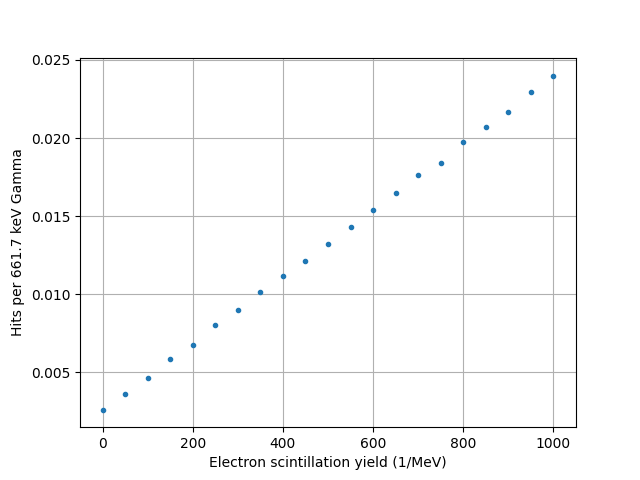

In [107]:
ufloat_values = [analysed_data[yield_val].hits_per_decay() for yield_val in yields]

yields = np.array(yields)
ufloat_values = np.array(ufloat_values)

plt.figure()
plt.errorbar(yields, [val.n for val in ufloat_values], yerr=[val.s for val in ufloat_values], fmt='.')
plt.xlabel('Electron scintillation yield (1/MeV)')
plt.ylabel('Hits per 661.7 keV Gamma')
plt.grid()
plt.show()


The Cs137 source was measured with Gamma spectroscopy and its activity was determined to be 631.8 kBq $\pm$ 11.8 kBq (sys).

<IPython.core.display.Javascript object>


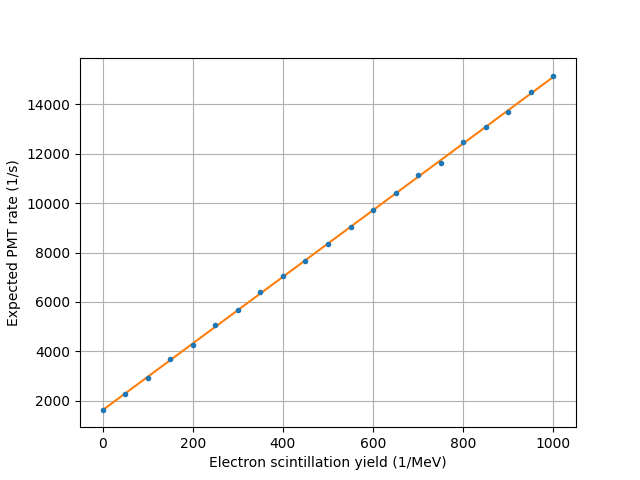

<IPython.core.display.Javascript object>


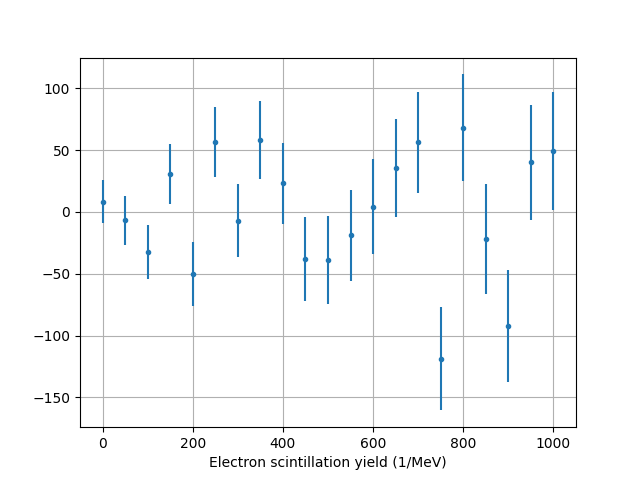

In [108]:
def lin(x,a,b):
    return x*a+b

CS137_activity = ufloat(631872, 11760)
pmt_rate = np.array(ufloat_values)*CS137_activity.n

popt,pcov = curve_fit(lin,yields, [val.n for val in pmt_rate], sigma=[val.s for val in pmt_rate], absolute_sigma=1 )
sim_slope, sim_const = uncertainties.correlated_values(popt, pcov)

plt.figure()
plt.errorbar(yields, [val.n for val in pmt_rate], yerr=[val.s for val in pmt_rate], fmt='.')
plt.plot(yields, lin(yields, *popt))
plt.xlabel('Electron scintillation yield (1/MeV)')
plt.ylabel('Expected PMT rate (1/s)')
plt.grid()
plt.show()

plt.figure()
plt.errorbar(yields, np.array([val.n for val in pmt_rate])-lin(yields, *popt), yerr=[val.s for val in pmt_rate], fmt='.')
plt.xlabel('Electron scintillation yield (1/MeV)')
plt.grid()
plt.show()


In [109]:
@dataclass
class Measurement:
    rate_sample : ufloat
    rate_background : ufloat
        
    @property
    def rate(self):
        return self.rate_sample-self.rate_background
    
    @property
    def threshold(self):
        return ufloat(0.3, 0.01) #Data was measured with lower threshold and then a cut at 0.3PE was performed. 
    
measured_data = {}        
with open("analysed_data_Okamot_Cs137_with_sample_AF_corrected.dat", "r") as f:
    for line in f:
        if "#" in line:
            continue
        temperature, _, _, rate, rate_err, _ = np.array(line.split()).astype("float")
        measured_data[temperature] = Measurement(ufloat(rate, rate_err), ufloat(rate, rate_err))
with open("analysed_data_Okamot_Cs137_background_AF_corrected.dat", "r") as f:
    for line in f:
        if "#" in line:
            continue
        temperature, _, _, rate, rate_err, _ = np.array(line.split()).astype("float")
        measured_data[temperature].rate_background= ufloat(rate, rate_err)
        
print(measured_data)

{-50.0: Measurement(rate_sample=13976.595926508071+/-56.88709056621227, rate_background=7280.899660863023+/-8.536720547928988), -40.0: Measurement(rate_sample=12701.66012394726+/-9.839563945953968, rate_background=6582.347322274894+/-12.464648864509243), -30.0: Measurement(rate_sample=11586.45911308943+/-8.213513220602552, rate_background=5969.103817805766+/-7.962381416541651), -25.0: Measurement(rate_sample=11085.169887643418+/-8.787610770089865, rate_background=5643.250815976784+/-10.637283034372665), -20.0: Measurement(rate_sample=10596.967517102095+/-7.420854676135321, rate_background=5336.468083510155+/-12.668607840529997), -15.0: Measurement(rate_sample=10129.171088171483+/-7.459934364166014, rate_background=5082.330517069289+/-9.155325504740262), -10.0: Measurement(rate_sample=9704.58813750085+/-8.215811232652909, rate_background=4842.797294528439+/-9.184190743661999), -5.0: Measurement(rate_sample=9294.179979959545+/-7.1636312647345015, rate_background=4597.673758702045+/-9.307

In [98]:
def get_yield(obj, rates):
    popt,pcov = curve_fit(lin,yields, [val.n for val in rates], sigma=[val.s for val in rates], absolute_sigma=1 )
    sim_slope, sim_const = uncertainties.correlated_values(popt, pcov)
    e_yield = (obj.rate-sim_const)/sim_slope
    return e_yield

def get_yield_with_systematics(obj: Measurement):
    baseline_rates = [CS137_activity.n*analysed_data[yield_val].hits_per_decay(obj.threshold.n) for yield_val in yields]
    baseline_yield = get_yield(obj, baseline_rates)
    print(f"Yield: {baseline_yield}")
    #Sys uncertainty from threshold
    yield_sys = []
    for pe_threshold in np.random.normal(obj.threshold.n, obj.threshold.s, 1000):
        rates = [CS137_activity*analysed_data[yield_val].hits_per_decay(pe_threshold) for yield_val in yields]
        yield_sys.append(get_yield(obj, rates).n)
    sys_pe = np.std(yield_sys)
        
    #Sys uncertainty from source activity
    rates = [CS137_activity*analysed_data[yield_val].hits_per_decay(obj.threshold.n) for yield_val in yields]
    sys_activity_yield = get_yield(obj, rates).s
    
    print(f"Systematic error from source activity {sys_activity_yield} and PE threshold {sys_pe} (1/MeV)")
    
    return baseline_yield, np.sqrt(sys_activity_yield**2+sys_pe**2)



In [110]:
for key, obj in measured_data.items():
    e_yields, u_sys = get_yield_with_systematics(obj)
    obj.calculated_yield = e_yields
    obj.yield_systematic_error = u_sys
    

Yield: 382+/-4
Systematic error from source activity 4.826693003666408 and PE threshold 0.7876840250288301 (1/MeV)
Yield: 338.9+/-1.3
Systematic error from source activity 2.2787141504463526 and PE threshold 0.6974907147722437 (1/MeV)
Yield: 301.2+/-1.0
Systematic error from source activity 1.9812760411101815 and PE threshold 0.6396679138458161 (1/MeV)
Yield: 288.0+/-1.2
Systematic error from source activity 2.0224938396745333 and PE threshold 0.5963895263351386 (1/MeV)
Yield: 274.4+/-1.2
Systematic error from source activity 2.0182381287312823 and PE threshold 0.5549849969908597 (1/MeV)
Yield: 258.3+/-1.0
Systematic error from source activity 1.8650565465474902 and PE threshold 0.5191009444947179 (1/MeV)
Yield: 244.4+/-1.1
Systematic error from source activity 1.850787960119955 and PE threshold 0.5310117969076492 (1/MeV)
Yield: 232.0+/-1.0
Systematic error from source activity 1.8035313917137035 and PE threshold 0.49783251573060383 (1/MeV)


<IPython.core.display.Javascript object>


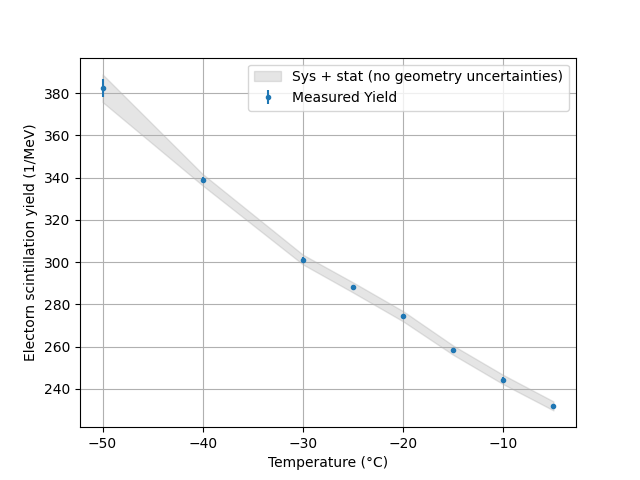

In [111]:
temperatures = np.array(list(measured_data.keys()))
yields = np.array([measured_data[temp].calculated_yield.nominal_value for temp in temperatures])
yields_err = np.array([measured_data[temp].calculated_yield.std_dev for temp in temperatures])
sys_err = np.array([measured_data[temp].yield_systematic_error for temp in temperatures])
sys_err = np.sqrt(sys_err*sys_err + yields_err*yields_err)
plt.figure()
# Plotting
plt.errorbar(temperatures, yields, yerr=yields_err, fmt='.', label='Measured Yield')
plt.fill_between(temperatures, yields - sys_err, yields + sys_err, color='gray', alpha=0.2, label='Sys + stat (no geometry uncertainties)')

# Labels and legend
plt.xlabel('Temperature (°C)')
plt.ylabel('Electorn scintillation yield (1/MeV)')
plt.grid()
plt.legend()

# Show pl

To estimate the systematic uncertainty, we assume that the ratio of emitted Cherenkov $C$ to emitted scintillation light for a given electron yield $y$, $S(y) = y\cdot E_{deposited}$ is independent of position variations of the different components in the setup. This would mean that in a setup where we have less deposited energy (because for example the source if further away from the sample), the relative Cherenkov light intensity will reduce the same amount. This is obviously not true, but probably ok, as the setup geometry variations are small. Under this assumption, the total number of hits on PMT will be a $\epsilon \cdot (C+S)$, where $\epsilon$ is a geometry factor. 

Now, we simulate the setup varying all positions with their respective uncertainties at the average yield. Then we repeat this variation at yield = 0, to verify our assumption above.

In [42]:
average_yield = np.mean(yields)
N_simulated = 1000000
hits_per_decay = []
for n in tqdm(range(500)):
    os.system(f"./OMSim_scintillation_yield -n {N_simulated} --detector_type 0 --detail_pmt --yield_alphas 0 --yield_electrons {average_yield} --output_file tmp --systematics")
    tmp = SimulationData(*np.loadtxt(f"tmp_hits.dat", unpack=1, usecols=(0,1,3,7,8,9)))
    tmp.process_data(N_simulated)
    hits_per_decay.append(tmp.hits_per_decay())
    os.system("rm -rf tmp_*.dat")
    os.system("rm -rf tmp_*.json")

  0%|          | 0/500 [00:00<?, ?it/s]

In [48]:
np.savetxt("systematics_average_yield.dat", ([val.n for val in hits_per_decay], [val.s for val in hits_per_decay]))

In [45]:
hitrate = [val.n for val in hits_per_decay]
hitratest = [val.s for val in hits_per_decay]
print(np.std(hitrate)*100/np.mean(hitrate), np.mean(hitratest)*100/np.mean(hitrate))

1.2694661581723736 0.5134306817231776


In [55]:
#Substract statistical uncertainty from systematics
rel_sys_stat = np.std(hitrate)/np.mean(hitrate)
rel_stat = np.mean(hitratest)/np.mean(hitrate)
systematic_relative = np.sqrt(rel_sys_stat**2 - rel_stat**2)
print(f"Relative systematic uncertainty from geometry errors in setup: {round(systematic_relative*100,2)} %")

Relative systematic uncertainty from geometry errors in setup: 1.16 %


We repeat now with electron yield 0, to check if assumption above was okeish 

In [83]:

N_simulated = 1000000
hits_per_decay = []
for n in tqdm(range(250)):
    os.system(f"./OMSim_scintillation_yield -n {N_simulated} --detector_type 0 --detail_pmt --yield_alphas 0 --yield_electrons {0} --output_file tmp --systematics")
    tmp = SimulationData(*np.loadtxt(f"tmp_hits.dat", unpack=1, usecols=(0,1,3,7,8,9)))
    tmp.process_data(N_simulated)
    hits_per_decay.append(tmp.hits_per_decay())
    os.system("rm -rf tmp_*.dat")
    os.system("rm -rf tmp_*.json")

  0%|          | 0/250 [00:00<?, ?it/s]

In [87]:
np.savetxt("systematics_average_0yield.dat", ([val.n for val in hits_per_decay], [val.s for val in hits_per_decay]))

In [84]:
hitrate = [val.n for val in hits_per_decay]
hitratest = [val.s for val in hits_per_decay]
print(np.std(hitrate)*100/np.mean(hitrate), np.mean(hitratest)*100/np.mean(hitrate))

1.6596750387861363 1.0386468571007406


In [101]:
#Substract statistical uncertainty from systematics
rel_sys_stat = np.std(hitrate)/np.mean(hitrate)
rel_stat = np.mean(hitratest)/np.mean(hitrate)
systematic_relative = np.sqrt(rel_sys_stat**2 - rel_stat**2)
print(f"Relative systematic uncertainty from geometry errors in setup (yield = 0): {round(systematic_relative*100,2)} %")

Relative systematic uncertainty from geometry errors in setup (yield = 0): 1.29 %


<IPython.core.display.Javascript object>


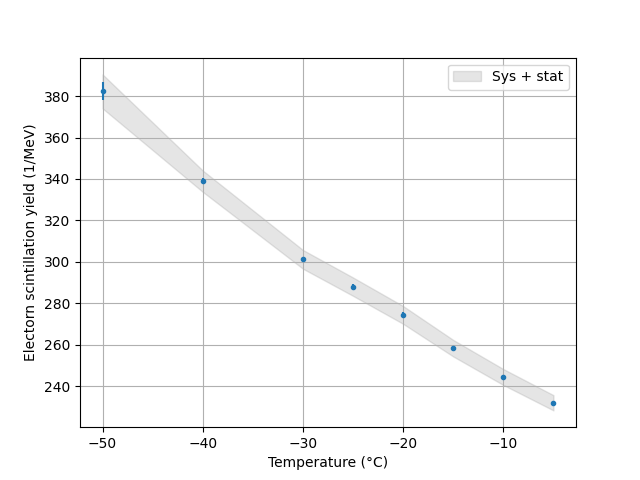

In [112]:
#Include geometry sys uncertainty 
temperatures = np.array(list(measured_data.keys()))
yields = np.array([measured_data[temp].calculated_yield.nominal_value for temp in temperatures])
yields_err = np.array([measured_data[temp].calculated_yield.std_dev for temp in temperatures])
sys_err = np.array([measured_data[temp].yield_systematic_error for temp in temperatures])
sys_err = np.sqrt(sys_err*sys_err + yields_err*yields_err + yields*yields*systematic_relative*systematic_relative)
plt.figure()
# Plotting
plt.errorbar(temperatures, yields, yerr=yields_err, fmt='.')
plt.fill_between(temperatures, yields - sys_err, yields + sys_err, color='gray', alpha=0.2, label='Sys + stat')

# Labels and legend
plt.xlabel('Temperature (°C)')
plt.ylabel('Electorn scintillation yield (1/MeV)')
plt.grid()
plt.legend()


In [113]:
np.savetxt("okamoto_electron_yield_01mmStep.dat", np.array([temperatures, yields, yields_err, sys_err]).T,header=("Temperature \t electron_yield(1/Mev) \t yield_error_statistical \t yield_error_sys+statistical"))